# FIP 02 — NE-only events: NE and DA transient dissociation

`fip_00_explore.ipynb`'s "NE"-only-onsets-aligned-to-movement figure (formerly in
`fip_01_movement_value_coding.ipynb`, removed there) treated every PL-GCaMP ("NE") onset the
same way. This notebook asks a sharper question: **which NE transients happen without a
concurrent DA transient**, versus NE transients where DA also surges — and whether movement
(motion energy, ME) looks different around those two kinds of NE event.

**"NE"**: this dataset's curation has no norepinephrine (nLight) sensor; per-project convention
the PL-GCaMP channel stands in for NE. **"DA"**: NAc dLight.

**Classification**: for each NE onset, detect DA onsets independently with the same
`threshold_onsets()` used throughout this notebook family; an NE onset is **NE+DA** if a DA
onset falls within ±0.5 s of it, otherwise **NE-only**. Four analyses characterize the
relationship beyond that binary split (DA peak distribution, a shuffle control for the
coincidence rate, onset-lag distribution, and peak-amplitude correlation) before the main
figure (ME aligned to each group). See the implementation plan
(`fip_02_ne_only_events` plan, 2026-09-14) for the full design rationale.

Setup (loading, curation, session select, example channels, motion energy, signal helpers)
comes from the shared `fip_utils.py` module, which `fip_00_explore.ipynb` and
`fip_01_movement_value_coding.ipynb` also use.

## Imports & setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Shared fip_* setup: loading, curation, session select, example channels, motion energy on
# the FIP clock, and the signal helpers (zscore / threshold_onsets / peri_event / norm_xcorr).
# autoreload so editing fip_utils.py doesn't cost a kernel restart + a full session reload.
%load_ext autoreload
%autoreload 2
import fip_utils as fu

# zscore_fip -- the same z-scoring Rachel's pipeline uses (see
# fip_01_movement_value_coding.ipynb for the full trace). This notebook needs only this one
# normalization, not the per-trial pipeline; see "Attach ME and z-score" below.
from aind_dynamic_foraging_data_utils import enrich_dfs

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)


## Data loading and curation

`fu.load_curated_sessions` wraps `load_nwb_list` + `apply_curation_nwb_list`, including the
patch for `data_curation_helpers.apply_curation_nwb_list`'s missing private-helper imports and
the `drop_borderline=False` / free-the-raw-list memory fix (the raw list is a function local
there, so it is released on return).


In [ ]:
nwb_list = fu.load_curated_sessions()


## Data processing

### Select a session


In [ ]:
SESSION_IDX = 0
nwb, df_fip, df_trials = fu.select_session(nwb_list, SESSION_IDX)


In [ ]:
meta = fu.build_meta(df_fip)
print(f"{len(meta)} FIP series (pearsonR excluded)")
meta


### NE and DA example channels

Same `pick_example` selection logic used throughout this notebook family (prefers a `dff`
variant, then most finite samples) -- here picking one representative NE (PL-GCaMP) channel and
one representative DA (NAc dLight) channel for this session.

In [ ]:
ne_info = fu.pick_example(meta, df_fip, "Gcamp")
da_info = fu.pick_example(meta, df_fip, "dLight")
NE_EVENT, DA_EVENT = ne_info["event"], da_info["event"]
print(f"NE (PL-GCaMP): {NE_EVENT}  | region: {ne_info['region']}")
print(f"DA (NAc dLight): {DA_EVENT}  | region: {da_info['region']}")
pd.DataFrame([ne_info, da_info])[["region", "event", "channel", "variant"]]


### Motion energy on the FIP clock

`fu.locate_me_assets` finds this session's behavior-video and motion-energy assets;
`fu.motion_energy_to_session` puts per-frame ME on the first-go-cue-zeroed session clock (the
`df_fip` axis), including the leading-zero pad for aind-motion-energy's N−1 frame output.


In [ ]:
video_csv, me_path = fu.locate_me_assets(nwb.session_id)
print("video_csv:", video_csv)
print("me_path:  ", me_path)


In [ ]:
t_me, me, offset = fu.motion_energy_to_session(me_path, video_csv, df_trials)

# Verify before trusting: offset small & positive, ME/FIP time ranges overlap.
print(f"offset = {offset:.3f} s | ME {t_me.min():.1f}..{t_me.max():.1f}s | "
      f"FIP {df_fip['timestamps'].min():.1f}..{df_fip['timestamps'].max():.1f}s")


### Attach ME and z-score everything

`fu.attach_me_to_df_fip` stores **raw** motion energy (not pre-z-scored) so it goes through
`zscore_fip` identically to a real FIP channel — those functions z-score `data` themselves, so
pre-z-scored input would be silently double-processed.

Unlike `fip_01_movement_value_coding.ipynb`, this notebook needs only the continuous-time
`data_z` column, not the per-trial `enrich_fip_in_df_trials` / `remove_tonic_df_fip`
baseline/tonic pipeline — the analysis below works entirely with onset times, not per-trial
windows. Everything downstream reads `data_z`, including `fu.threshold_onsets` (via
`already_z=True`), so one normalization convention runs throughout.


In [ ]:
df_fip = fu.attach_me_to_df_fip(df_fip, t_me, me, nwb.session_id)
df_fip_z = enrich_dfs.zscore_fip(df_fip)
nwb.df_fip = df_fip_z

# data_z throughout: onset detection, peaks and plotting all read the same upstream-normalized
# column, so there is one z-scoring convention in this notebook.
t_ne, ne_z = fu.get_trace(df_fip_z, NE_EVENT, data_col="data_z")
t_da, da_z = fu.get_trace(df_fip_z, DA_EVENT, data_col="data_z")
t_me_z, me_z = fu.get_trace(df_fip_z, "ME", data_col="data_z")

print(f"NE: {len(t_ne)} samples | DA: {len(t_da)} samples | ME: {len(t_me_z)} samples")


## NE and DA raw traces — visual overview

Before any quantitative analysis: a `TRACE_WINDOW_DUR`-second window of both z-scored traces
overlaid, to get a qualitative sense of how correlated (or not) NE and DA look before
quantifying it below. Change `TRACE_WINDOW_START` (or call `plot_ne_da_window` again with a
different start time) to scan other parts of the session.

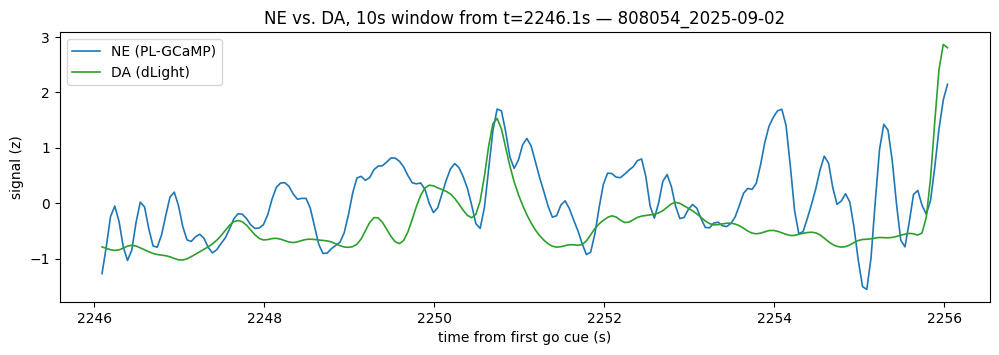

In [83]:
TRACE_WINDOW_DUR = 10.0  # seconds -- window length
TRACE_WINDOW_START = float(t_ne.min() + (t_ne.max() - t_ne.min()) / 2)  # default: mid-session


def plot_ne_da_window(t_start, duration=TRACE_WINDOW_DUR):
    t_end = t_start + duration
    m_ne = (t_ne >= t_start) & (t_ne <= t_end)
    m_da = (t_da >= t_start) & (t_da <= t_end)
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(t_ne[m_ne], ne_z[m_ne], color="#1f77b4", lw=1.2, label="NE (PL-GCaMP)")
    ax.plot(t_da[m_da], da_z[m_da], color="#2ca02c", lw=1.2, label="DA (dLight)")
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("signal (z)")
    ax.set_title(f"NE vs. DA, {duration:.0f}s window from t={t_start:.1f}s — {nwb.session_id}")
    ax.legend()
    plt.show()


plot_ne_da_window(TRACE_WINDOW_START)

## NE↔DA cross-correlation

Session-wide lead/lag relationship between the two continuous traces, independent of onset
detection — resample both onto a common grid over their time overlap (same recipe
`fip_00_explore.ipynb` uses for motion energy × FIP), then `norm_xcorr`. **Positive lag = NE
leads DA**, chosen to match the sign convention used by the onset-lag distribution further
below (`da_onset - ne_onset`, positive when DA follows NE).

In [ ]:
FS_XC = 20    # Hz, common resampling grid
MAXLAG = 3.0  # s

xcorr_lo = max(t_ne.min(), t_da.min())
xcorr_hi = min(t_ne.max(), t_da.max())
xcorr_grid = np.arange(xcorr_lo, xcorr_hi, 1.0 / FS_XC)
ne_i = np.interp(xcorr_grid, t_ne, ne_z)
da_i = np.interp(xcorr_grid, t_da, da_z)

# b=ne_i -> positive lag means NE leads DA (see norm_xcorr's docstring for the sign convention).
xcorr_lags, xcorr = fu.norm_xcorr(da_i, ne_i, fs=FS_XC, maxlag=MAXLAG)
peak_lag = xcorr_lags[int(np.argmax(xcorr))]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xcorr_lags, xcorr, color="#9467bd")
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.axvline(peak_lag, color="#9467bd", lw=1, ls="--", alpha=0.6)
ax.set_xlabel("lag (s)   —   positive = NE leads DA")
ax.set_ylabel("normalised cross-correlation")
ax.set_title(f"NE↔DA cross-correlation — {nwb.session_id} (peak at {peak_lag:+.2f}s)")
plt.show()

print(f"Peak cross-correlation at lag {peak_lag:+.2f}s (value={xcorr.max():.3f})")

## Onset detection and NE-only / NE+DA classification

`fu.threshold_onsets` on the upstream `data_z` traces (`already_z=True`, so it does not
re-z-score). `MIN_RUN` is in **samples**, not seconds — at FIP's ~20 Hz, `MIN_RUN=10` requires
the crossing to persist ~0.5 s. `WINDOW` is the NE↔DA coincidence window: an NE onset counts as
NE+DA if any DA onset falls within it.

These detection parameters are the tunable knobs of this analysis; the z-threshold sensitivity
sweep at the end of the notebook reruns everything across `z_thresh` to show how much of the
result depends on this particular choice.


In [ ]:
Z_THRESH = 1.0
REFRACTORY = 0.5
MIN_RUN = 10
WINDOW = 1  # seconds, NE<->DA coincidence window

# already_z=True: these traces are the upstream data_z column, so threshold_onsets must not
# z-score them a second time.
ne_onsets = fu.threshold_onsets(t_ne, ne_z, z_thresh=Z_THRESH, refractory=REFRACTORY,
                                min_run=MIN_RUN, already_z=True)
da_onsets = fu.threshold_onsets(t_da, da_z, z_thresh=Z_THRESH, refractory=REFRACTORY,
                                min_run=MIN_RUN, already_z=True)
print(f"{len(ne_onsets)} NE onsets, {len(da_onsets)} DA onsets (z>{Z_THRESH})")

if len(da_onsets):
    ne_da_dists = np.abs(ne_onsets[:, None] - da_onsets[None, :])
    has_da = (ne_da_dists <= WINDOW).any(axis=1)
else:
    has_da = np.zeros(len(ne_onsets), dtype=bool)

ne_only_onsets = ne_onsets[~has_da]
ne_da_onsets = ne_onsets[has_da]

print(f"  {len(ne_only_onsets)} NE-only (no DA onset within ±{WINDOW}s)")
print(f"  {len(ne_da_onsets)} NE+DA (DA onset within ±{WINDOW}s)")


### QC — example onsets from each group

Sanity check before trusting the aggregate analyses below: NE-only examples should visibly lack
a DA co-transient; NE+DA examples should show one.

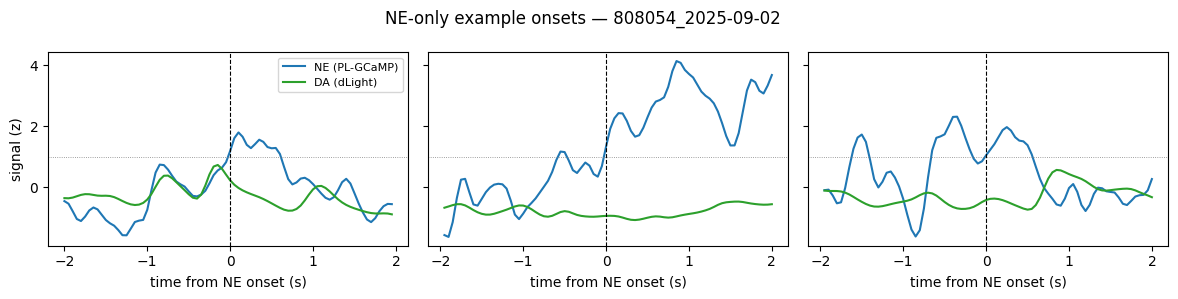

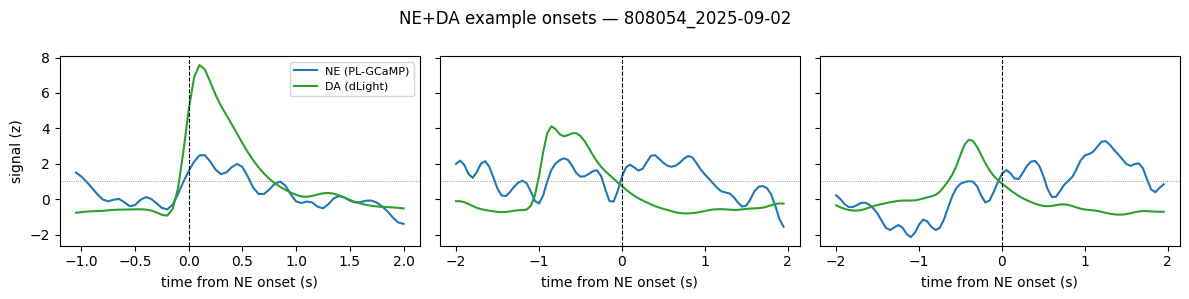

In [100]:
def plot_example_onsets(onset_times, title, n=3, window=2.0):
    n = min(n, len(onset_times))
    if n == 0:
        print(f"No examples for: {title}")
        return
    picks = onset_times[np.linspace(0, len(onset_times) - 1, n).astype(int)]
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, onset in zip(axes, picks):
        m_ne = (t_ne >= onset - window) & (t_ne <= onset + window)
        m_da = (t_da >= onset - window) & (t_da <= onset + window)
        ax.plot(t_ne[m_ne] - onset, ne_z[m_ne], color="#1f77b4", label="NE (PL-GCaMP)")
        ax.plot(t_da[m_da] - onset, da_z[m_da], color="#2ca02c", label="DA (dLight)")
        ax.axvline(0, color="k", lw=0.8, ls="--")
        ax.axhline(Z_THRESH, color="gray", lw=0.6, ls=":")
        ax.set_xlabel("time from NE onset (s)")
    axes[0].set_ylabel("signal (z)")
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_example_onsets(ne_only_onsets, f"NE-only example onsets — {nwb.session_id}")
plot_example_onsets(ne_da_onsets, f"NE+DA example onsets — {nwb.session_id}")

## Quantitative NE–DA relationship analyses

The onset-coincidence split above is a hard cutoff through what might be a continuum. Four
analyses characterize the relationship itself, beyond that binary split.

### DA peak distribution around NE onsets

For *every* NE onset (not just the NE+DA subset), the max DA (z) within ±`WINDOW` of it.
Bimodal = the NE-only/NE+DA split is a real dichotomy; smeared/continuous = the split is
cutting through a continuum and should be caveated as such.

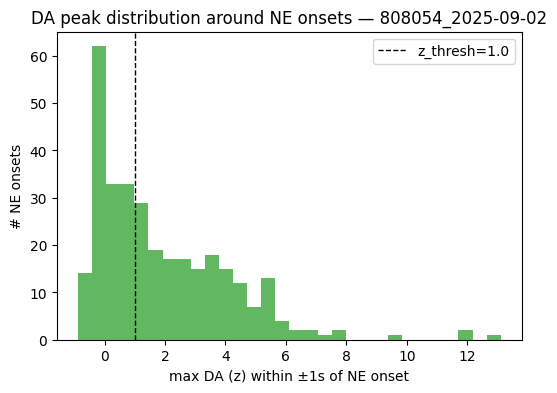

In [101]:
def peak_in_window(t, z, centers, window):
    """max(z) within [center-window, center+window] for each center; NaN if no samples."""
    out = np.full(len(centers), np.nan)
    for i, c in enumerate(centers):
        m = (t >= c - window) & (t <= c + window)
        if m.any():
            out[i] = np.nanmax(z[m])
    return out


da_peak_z = peak_in_window(t_da, da_z, ne_onsets, WINDOW)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(da_peak_z, bins=30, color="#2ca02c", alpha=0.75)
ax.axvline(Z_THRESH, color="k", lw=1, ls="--", label=f"z_thresh={Z_THRESH}")
ax.set_xlabel(f"max DA (z) within ±{WINDOW}s of NE onset")
ax.set_ylabel("# NE onsets")
ax.set_title(f"DA peak distribution around NE onsets — {nwb.session_id}")
ax.legend()
plt.show()

### Shuffle control for the coincidence rate

Circular-shift the DA onset train by a random offset (wrapped within the session's time range),
~1000 times, recomputing the NE+DA coincidence rate each time. Compares the observed rate
against this null to ask whether the overlap is more than each signal's own baseline event rate
would produce by chance.

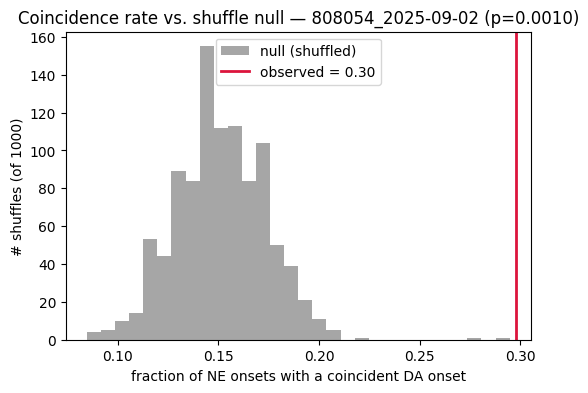

Observed: 0.298 | shuffle null mean: 0.151 | empirical p-value: 0.0010


In [102]:
N_SHUFFLES = 1000
rng = np.random.default_rng(0)

t_min = float(min(t_ne.min(), t_da.min()))
t_max = float(max(t_ne.max(), t_da.max()))
session_dur = t_max - t_min


def coincidence_rate(ne_t, da_t, window):
    if len(da_t) == 0 or len(ne_t) == 0:
        return 0.0
    d = np.abs(ne_t[:, None] - da_t[None, :])
    return (d <= window).any(axis=1).mean()


observed_rate = coincidence_rate(ne_onsets, da_onsets, WINDOW)

null_rates = np.empty(N_SHUFFLES)
for i in range(N_SHUFFLES):
    shift = rng.uniform(0, session_dur)
    da_shifted = t_min + (da_onsets - t_min + shift) % session_dur
    null_rates[i] = coincidence_rate(ne_onsets, da_shifted, WINDOW)

p_value = (np.sum(null_rates >= observed_rate) + 1) / (N_SHUFFLES + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(null_rates, bins=30, color="gray", alpha=0.7, label="null (shuffled)")
ax.axvline(observed_rate, color="crimson", lw=2, label=f"observed = {observed_rate:.2f}")
ax.set_xlabel("fraction of NE onsets with a coincident DA onset")
ax.set_ylabel(f"# shuffles (of {N_SHUFFLES})")
ax.set_title(f"Coincidence rate vs. shuffle null — {nwb.session_id} (p={p_value:.4f})")
ax.legend()
plt.show()

print(f"Observed: {observed_rate:.3f} | shuffle null mean: {null_rates.mean():.3f} "
      f"| empirical p-value: {p_value:.4f}")

### Lag distribution for coincident pairs

For each NE+DA onset, the nearest DA onset's time minus the NE onset's time — does DA tend to
lead, lag, or center on NE?

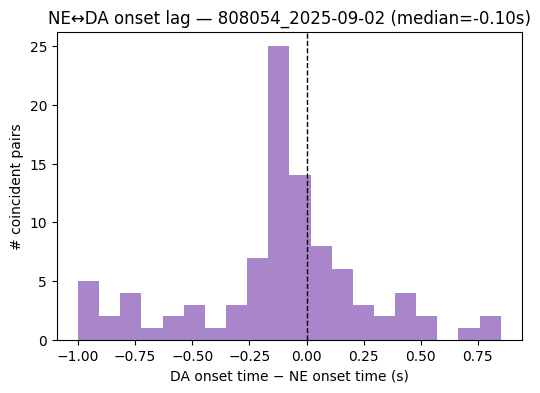

median lag: -0.100s | mean lag: -0.118s


In [103]:
if len(ne_da_onsets) and len(da_onsets):
    lags = np.array([
        da_onsets[np.argmin(np.abs(da_onsets - onset))] - onset
        for onset in ne_da_onsets
    ])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(lags, bins=20, color="#9467bd", alpha=0.8)
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.set_xlabel("DA onset time − NE onset time (s)")
    ax.set_ylabel("# coincident pairs")
    ax.set_title(f"NE↔DA onset lag — {nwb.session_id} (median={np.median(lags):+.2f}s)")
    plt.show()
    print(f"median lag: {np.median(lags):+.3f}s | mean lag: {lags.mean():+.3f}s")
else:
    print("No coincident NE+DA pairs to compute lag for.")

### Amplitude correlation

For coincident pairs, NE peak amplitude (max NE z-score shortly after each NE onset) vs. DA
peak amplitude (`da_peak_z`, computed above, restricted to the NE+DA subset) — does a bigger NE
transient come with a bigger concurrent DA transient?

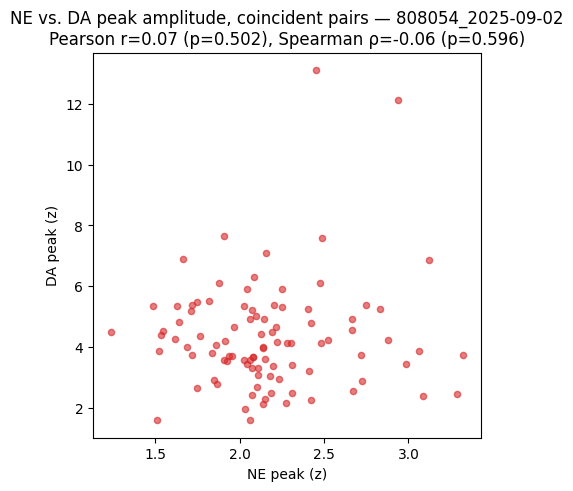

In [104]:
ne_peak_z = peak_in_window(t_ne, ne_z, ne_da_onsets, WINDOW)
da_peak_z_coincident = da_peak_z[has_da]

valid = np.isfinite(ne_peak_z) & np.isfinite(da_peak_z_coincident)
if valid.sum() >= 3:
    r_pearson, p_pearson = stats.pearsonr(ne_peak_z[valid], da_peak_z_coincident[valid])
    r_spearman, p_spearman = stats.spearmanr(ne_peak_z[valid], da_peak_z_coincident[valid])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(ne_peak_z[valid], da_peak_z_coincident[valid], s=20, alpha=0.6, color="#d62728")
    ax.set_xlabel("NE peak (z)")
    ax.set_ylabel("DA peak (z)")
    ax.set_title(f"NE vs. DA peak amplitude, coincident pairs — {nwb.session_id}\n"
                f"Pearson r={r_pearson:.2f} (p={p_pearson:.3f}), "
                f"Spearman ρ={r_spearman:.2f} (p={p_spearman:.3f})")
    plt.show()
else:
    print(f"Only {int(valid.sum())} valid coincident pairs -- too few for a correlation.")

## Main figure — motion energy aligned to NE-only vs. NE+DA onsets

`peri_event` on z-scored ME, `censor=False` (movement onsets are closely spaced — same
rationale documented in `fip_00_explore.ipynb`'s onset-alignment cells), one trace per group.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for onsets, label, color in [(ne_only_onsets, f"NE-only (n={len(ne_only_onsets)})", "#1f77b4"),
                             (ne_da_onsets, f"NE+DA (n={len(ne_da_onsets)})", "#d62728")]:
    if len(onsets) == 0:
        print(f"No onsets for {label}; skipping.")
        continue
    etr = fu.peri_event(t_me_z, me_z, onsets, t_before=2.0, t_after=4.0, censor=False)
    if etr is None or etr.empty:
        print(f"No ETR for {label}; skipping.")
        continue
    g = etr.groupby("time")["data"]
    mean, sem = g.mean(), g.sem()
    ax.plot(mean.index, mean.values, color=color, lw=2, label=label)
    ax.fill_between(mean.index, (mean - sem).values, (mean + sem).values, color=color, alpha=0.25)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("time from NE onset (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title(f"Movement aligned to NE-only vs. NE+DA onsets — {nwb.session_id}")
ax.legend()
plt.show()

## Z-threshold sensitivity sweep

Every analysis above runs at a single `Z_THRESH` (set in the onset-detection cell above).
How much of the NE-only/NE+DA story depends on that specific choice? This section reruns
onset detection and all four quantitative analyses -- shuffle control, lag distribution,
peak-amplitude correlation, and the ME-alignment comparison -- across a sweep of detection
thresholds from z=1 to z=3, one four-panel summary figure per threshold.

This is a robustness check, not a new claim: `REFRACTORY`, `MIN_RUN`, and the NE<->DA
coincidence `WINDOW` are held fixed at their values above, only `z_thresh` varies. The
shuffle control here uses fewer resamples (`N_SHUFFLES_SWEEP=500` vs. `N_SHUFFLES=1000`
above) since the whole pipeline reruns once per sweep point.

In [ ]:
N_SHUFFLES_SWEEP = 500
Z_SWEEP = np.arange(1.0, 3.01, 0.5)  # 1.0, 1.5, 2.0, 2.5, 3.0


def analyze_at_zthresh(z_thresh, *, refractory=REFRACTORY, min_run=MIN_RUN, window=WINDOW,
                        n_shuffles=N_SHUFFLES_SWEEP, rng=None):
    """Rerun onset detection, classification, and the four downstream analyses at one z_thresh.

    Reuses `fu.threshold_onsets`, `peak_in_window`, `fu.peri_event`, and `coincidence_rate`
    exactly as the main analysis above calls them -- only the detection threshold
    changes. Results are returned rather than assigned at module level, so the sweep
    can't clobber the main analysis's `ne_onsets`/`lags`/etc. variables.

    Parameters
    ----------
    z_thresh : float
        Onset-detection threshold (z-score), passed to `fu.threshold_onsets` for both NE
        and DA.
    refractory, min_run, window : float
        Held fixed across the sweep at the notebook's main-analysis values
        (`REFRACTORY`, `MIN_RUN`, `WINDOW`).
    n_shuffles : int
        Shuffle count for the coincidence-rate null.
    rng : numpy.random.Generator, optional
        Defaults to a fresh `default_rng(0)` per call, so every threshold draws the same
        shuffle sequence and differences across the sweep come only from `z_thresh`.

    Returns
    -------
    dict
        z_thresh, ne_onsets, da_onsets, ne_only_onsets, ne_da_onsets, observed_rate,
        null_rates, p_value, lags, ne_peak_z, da_peak_z_coincident, r_pearson,
        p_pearson, r_spearman, p_spearman, etr_ne_only, etr_ne_da.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    ne_onsets_z = fu.threshold_onsets(t_ne, ne_z, z_thresh=z_thresh, refractory=refractory,
                                      min_run=min_run, already_z=True)
    da_onsets_z = fu.threshold_onsets(t_da, da_z, z_thresh=z_thresh, refractory=refractory,
                                      min_run=min_run, already_z=True)

    if len(da_onsets_z):
        d = np.abs(ne_onsets_z[:, None] - da_onsets_z[None, :])
        has_da_z = (d <= window).any(axis=1)
    else:
        has_da_z = np.zeros(len(ne_onsets_z), dtype=bool)
    ne_only_z = ne_onsets_z[~has_da_z]
    ne_da_z = ne_onsets_z[has_da_z]

    # Shuffle control (same circular-shift recipe as the main analysis's coincidence_rate cell)
    observed_rate = coincidence_rate(ne_onsets_z, da_onsets_z, window)
    null_rates = np.empty(n_shuffles)
    for i in range(n_shuffles):
        shift = rng.uniform(0, session_dur)
        da_shifted = t_min + (da_onsets_z - t_min + shift) % session_dur
        null_rates[i] = coincidence_rate(ne_onsets_z, da_shifted, window)
    p_value = (np.sum(null_rates >= observed_rate) + 1) / (n_shuffles + 1)

    # Lag distribution for coincident pairs
    if len(ne_da_z) and len(da_onsets_z):
        lags = np.array([
            da_onsets_z[np.argmin(np.abs(da_onsets_z - onset))] - onset
            for onset in ne_da_z
        ])
    else:
        lags = np.array([])

    # Peak-amplitude correlation for coincident pairs
    da_peak_z_all = peak_in_window(t_da, da_z, ne_onsets_z, window)
    ne_peak_z_pts = peak_in_window(t_ne, ne_z, ne_da_z, window)
    da_peak_z_coincident = da_peak_z_all[has_da_z]
    valid = np.isfinite(ne_peak_z_pts) & np.isfinite(da_peak_z_coincident)
    if valid.sum() >= 3:
        r_pearson, p_pearson = stats.pearsonr(ne_peak_z_pts[valid], da_peak_z_coincident[valid])
        r_spearman, p_spearman = stats.spearmanr(ne_peak_z_pts[valid], da_peak_z_coincident[valid])
    else:
        r_pearson = p_pearson = r_spearman = p_spearman = np.nan

    # ME alignment, one ETR per group
    etr_ne_only = (fu.peri_event(t_me_z, me_z, ne_only_z, t_before=2.0, t_after=4.0, censor=False)
                   if len(ne_only_z) else None)
    etr_ne_da = (fu.peri_event(t_me_z, me_z, ne_da_z, t_before=2.0, t_after=4.0, censor=False)
                 if len(ne_da_z) else None)

    return dict(
        z_thresh=z_thresh, ne_onsets=ne_onsets_z, da_onsets=da_onsets_z,
        ne_only_onsets=ne_only_z, ne_da_onsets=ne_da_z,
        observed_rate=observed_rate, null_rates=null_rates, p_value=p_value, lags=lags,
        ne_peak_z=ne_peak_z_pts[valid], da_peak_z_coincident=da_peak_z_coincident[valid],
        r_pearson=r_pearson, p_pearson=p_pearson, r_spearman=r_spearman, p_spearman=p_spearman,
        etr_ne_only=etr_ne_only, etr_ne_da=etr_ne_da,
    )

In [ ]:
def plot_zthresh_summary(res):
    """Four-panel summary figure for one z_thresh: shuffle control, lag distribution,
    peak-amplitude correlation, and ME alignment -- the same four analyses run above at
    the notebook's main `Z_THRESH`, replicated at `res["z_thresh"]`.

    Parameters
    ----------
    res : dict
        Output of `analyze_at_zthresh`.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

    ax = axes[0, 0]
    ax.hist(res["null_rates"], bins=30, color="gray", alpha=0.7, label="null (shuffled)")
    ax.axvline(res["observed_rate"], color="crimson", lw=2,
               label=f"observed = {res['observed_rate']:.2f}")
    ax.set_xlabel("fraction of NE onsets with coincident DA onset")
    ax.set_ylabel("# shuffles")
    ax.set_title(f"Coincidence vs. shuffle null (p={res['p_value']:.4f})")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    if len(res["lags"]):
        ax.hist(res["lags"], bins=20, color="#9467bd", alpha=0.8)
        ax.axvline(0, color="k", lw=1, ls="--")
        ax.set_title(f"NE↔DA onset lag (median={np.median(res['lags']):+.2f}s)")
    else:
        ax.text(0.5, 0.5, "no coincident pairs", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("NE↔DA onset lag")
    ax.set_xlabel("DA onset time − NE onset time (s)")
    ax.set_ylabel("# coincident pairs")

    ax = axes[1, 0]
    if len(res["ne_peak_z"]) >= 3:
        ax.scatter(res["ne_peak_z"], res["da_peak_z_coincident"], s=18, alpha=0.6, color="#d62728")
        ax.set_title(f"NE vs. DA peak amplitude\n"
                    f"Pearson r={res['r_pearson']:.2f} (p={res['p_pearson']:.3f})")
    else:
        ax.text(0.5, 0.5, "too few coincident pairs", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("NE vs. DA peak amplitude")
    ax.set_xlabel("NE peak (z)")
    ax.set_ylabel("DA peak (z)")

    ax = axes[1, 1]
    for etr, label, color in [
        (res["etr_ne_only"], f"NE-only (n={len(res['ne_only_onsets'])})", "#1f77b4"),
        (res["etr_ne_da"], f"NE+DA (n={len(res['ne_da_onsets'])})", "#d62728"),
    ]:
        if etr is None or etr.empty:
            continue
        g = etr.groupby("time")["data"]
        mean, sem = g.mean(), g.sem()
        ax.plot(mean.index, mean.values, color=color, lw=2, label=label)
        ax.fill_between(mean.index, (mean - sem).values, (mean + sem).values, color=color, alpha=0.25)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("time from NE onset (s)")
    ax.set_ylabel("motion energy (z)")
    ax.set_title("ME aligned to NE-only vs. NE+DA")
    ax.legend(fontsize=8)

    fig.suptitle(f"z_thresh = {res['z_thresh']:.1f} — {nwb.session_id}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
sweep_rows = []
for z in Z_SWEEP:
    res = analyze_at_zthresh(float(z))
    plot_zthresh_summary(res)
    sweep_rows.append(dict(
        z_thresh=res["z_thresh"],
        n_ne=len(res["ne_onsets"]), n_da=len(res["da_onsets"]),
        n_ne_only=len(res["ne_only_onsets"]), n_ne_da=len(res["ne_da_onsets"]),
        observed_rate=res["observed_rate"], p_value=res["p_value"],
        median_lag=np.median(res["lags"]) if len(res["lags"]) else np.nan,
        r_pearson=res["r_pearson"], p_pearson=res["p_pearson"],
    ))

sweep_summary = pd.DataFrame(sweep_rows)
print(sweep_summary.to_string(index=False))